In [33]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from utils.model import build_resnet50
from utils.checkpoint import load_checkpoint
from utils.dataloaders import create_dataloaders
from utils.dataset import ChestXrayDataset

from utils.explainability import (
    generate_gradcam,
    generate_gradcam_plus_plus
)

from utils.integrated_gradients import (
    generate_integrated_gradients
)

from utils.evaluation import (
    normalize_map,
    threshold_map,
    resize_mask,
    compute_iou,
    pointing_game,
    heatmap_coverage,
    confidence_drop
)
from utils.explainability import generate_gradcam

In [35]:
if torch.backends.mps.is_available():
    device = torch.device("mps")

elif torch.cuda.is_available():
    device = torch.device("cuda")

else:
    device = torch.device("cpu")

print(device)

mps


In [36]:
model = build_resnet50()

model = load_checkpoint(
    model,
    "../checkpoints/best_resnet50.pth",
    device
)

model = model.to(device)   # <-- Add this

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [37]:
dataset_path = "../datasets/COVID-19_Radiography_Dataset"

(
    train_loader,
    val_loader,
    test_loader,
    train_df,
    val_df,
    test_df
) = create_dataloaders(
    dataset_path=dataset_path,
    batch_size=1,
    load_masks=True
)

print(f"Test Images: {len(test_df)}")

Test Images: 3175


In [38]:
class_names = {
    0: "COVID",
    1: "Normal",
    2: "Lung Opacity",
    3: "Viral Pneumonia"
}

In [39]:
images, masks, labels = next(iter(test_loader))

print("Image Shape :", images.shape)
print("Mask Shape  :", masks.shape)
print("Label       :", labels.item())

Image Shape : torch.Size([1, 3, 224, 224])
Mask Shape  : torch.Size([1, 1, 224, 224])
Label       : 1


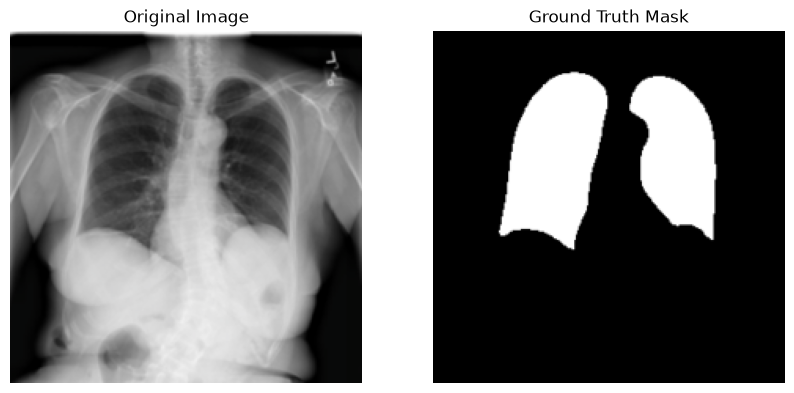

In [40]:
image = images.squeeze().permute(1, 2, 0).numpy()

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

image = image * std + mean
image = image.clip(0, 1)

mask = masks.squeeze().numpy()

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

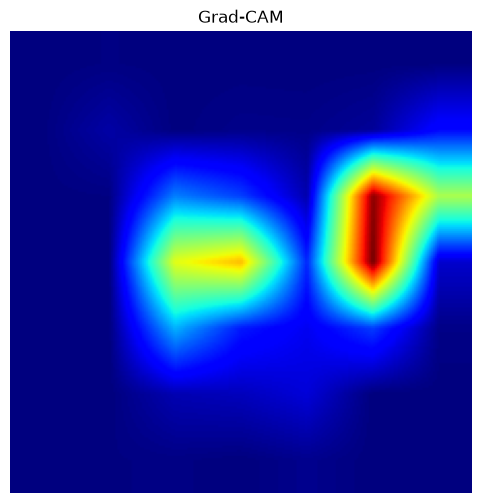

In [41]:
target_layers = [model.layer4[-1]]

images = images.to(device)

gradcam = generate_gradcam(
    model=model,
    input_tensor=images,
    target_layers=target_layers
)

gradcam = normalize_map(gradcam)

plt.figure(figsize=(6,6))
plt.imshow(gradcam, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")
plt.show()

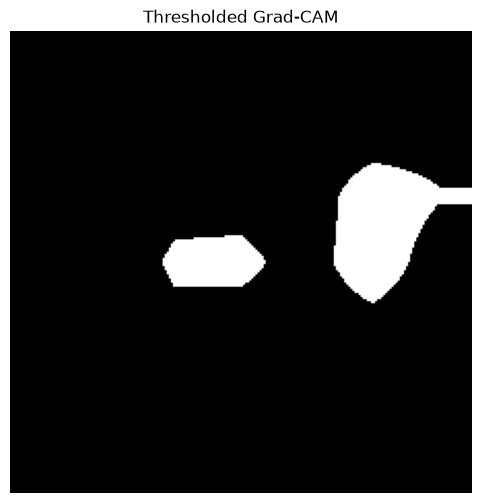

In [42]:
gradcam_binary = threshold_map(
    gradcam,
    threshold=0.5
)

plt.figure(figsize=(6,6))
plt.imshow(gradcam_binary, cmap="gray")
plt.title("Thresholded Grad-CAM")
plt.axis("off")
plt.show()

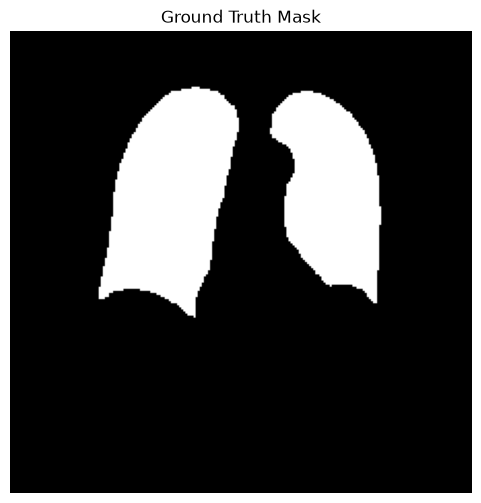

In [43]:
gt_mask = masks.squeeze().cpu().numpy()

gt_mask = resize_mask(
    gt_mask,
    gradcam.shape
)

gt_mask = (gt_mask > 0.5).astype(np.uint8)

plt.figure(figsize=(6,6))
plt.imshow(gt_mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")
plt.show()

In [44]:
iou = compute_iou(
    gradcam_binary,
    gt_mask
)

print(f"IoU Score: {iou:.4f}")

IoU Score: 0.1523


In [45]:
point = pointing_game(
    gradcam,
    gt_mask
)

print("Pointing Game:", point)

Pointing Game: 1


In [46]:
coverage = heatmap_coverage(
    gradcam,
    gt_mask,
    threshold=0.5
)

print(f"Heatmap Coverage : {coverage:.4f}")

Heatmap Coverage : 0.4611


In [47]:
drop = confidence_drop(
    model,
    images,
    gradcam,
    device
)

print(f"Confidence Drop : {drop:.4f}")

Confidence Drop : 0.0017


In [48]:
from tqdm import tqdm
import numpy as np

from utils.explainability import generate_gradcam
from utils.evaluation import (
    normalize_map,
    threshold_map,
    resize_mask,
    compute_iou,
    pointing_game,
    heatmap_coverage
)

# -----------------------------------------
# Target Layer
# -----------------------------------------

target_layers = [model.layer4[-1]]

# -----------------------------------------
# Store Metrics
# -----------------------------------------

ious = []
pointing_scores = []
coverages = []

model.eval()

# -----------------------------------------
# Evaluation Loop
# -----------------------------------------

for images, masks, labels in tqdm(test_loader, desc="Evaluating Grad-CAM"):

    images = images.to(device)
    labels = labels.to(device)

    # Generate Grad-CAM
    gradcam = generate_gradcam(
        model=model,
        input_tensor=images,
        target_layers=target_layers,
        target_class=labels.item()
    )

    # Normalize explanation
    gradcam = normalize_map(gradcam)

    # Threshold explanation
    gradcam_binary = threshold_map(
        gradcam,
        threshold=0.5
    )

    # Ground truth mask
    gt_mask = masks.squeeze().cpu().numpy()

    gt_mask = resize_mask(
        gt_mask,
        gradcam.shape
    )

    gt_mask = gt_mask > 0

    # ---------------- Metrics ----------------

    iou = compute_iou(
        gradcam_binary,
        gt_mask
    )

    point = pointing_game(
        gradcam,
        gt_mask
    )

    coverage = heatmap_coverage(
        gradcam,
        gt_mask,
        threshold=0.5
    )

    ious.append(iou)
    pointing_scores.append(point)
    coverages.append(coverage)

# -----------------------------------------
# Final Results
# -----------------------------------------

mean_iou = np.mean(ious)
pointing_accuracy = np.mean(pointing_scores)
mean_coverage = np.mean(coverages)

print("=" * 60)
print("Grad-CAM Evaluation Results")
print("=" * 60)

print(f"Mean IoU               : {mean_iou:.4f}")
print(f"Pointing Game Accuracy : {pointing_accuracy:.4f}")
print(f"Heatmap Coverage       : {mean_coverage:.4f}")

print("=" * 60)

Evaluating Grad-CAM: 100%|██████████| 3175/3175 [01:49<00:00, 29.11it/s]

Grad-CAM Evaluation Results
Mean IoU               : 0.1819
Pointing Game Accuracy : 0.7858
Heatmap Coverage       : 0.6252


In [49]:
from utils.evaluator import ExplainabilityEvaluator

In [50]:
evaluator = ExplainabilityEvaluator(
    model=model,
    test_loader=test_loader,
    device=device
)

In [51]:
gradcam_results = evaluator.evaluate_gradcam()

Evaluating Grad-CAM: 100%|██████████| 3175/3175 [01:48<00:00, 29.22it/s]


In [52]:
gradcampp_results = evaluator.evaluate_gradcampp()

Evaluating Grad-CAM++: 100%|██████████| 3175/3175 [01:48<00:00, 29.19it/s]


In [53]:
ig_results = evaluator.evaluate_integrated_gradients()

Evaluating Integrated Gradients: 100%|██████████| 3175/3175 [2:29:25<00:00,  2.82s/it]    


In [54]:
evaluator.save_results("results.csv")

                 Method  Mean IoU  Pointing Game  Heatmap Coverage
0              Grad-CAM  0.181913       0.785827          0.625205
1            Grad-CAM++  0.191681       0.796850          0.630021
2  Integrated Gradients  0.001222       0.203465          0.211615

Results saved to results.csv
